# So sánh, lựa chọn và phân tích mô hình dự báo đa chân trời

Notebook này lựa chọn mô hình tốt nhất trong ba candidate **SARIMAX, XGBoost và
LSTM** cho bài toán hồi quy PM2.5 từ `t+1` đến `t+24`.

## Nguyên tắc lựa chọn

1. Ba mô hình phải dự báo đúng cùng thành phố, thời điểm gốc và 24 chân trời.
2. Giai đoạn Validation được chia thành **5 khối thời gian liên tiếp**. Mỗi khối
   giữ nguyên thứ tự thời gian và chứa đủ ba thành phố, do đó không dùng K-fold
   ngẫu nhiên cho dữ liệu chuỗi thời gian.
3. Tiêu chí chính là **RMSE trung bình của 24 chân trời, trung bình qua 5 khối**.
   Độ lệch chuẩn, worst-fold RMSE và MAE là tiêu chí phụ.
4. Tập Test bị khóa cho đến khi tên mô hình thắng cuộc đã được xác định.

Phép chia khối ở đây là một **blocked temporal validation audit** trên các dự đoán
Validation ngoài mẫu của các candidate đã huấn luyện. Nó kiểm tra độ ổn định theo
thời gian tốt hơn một điểm Validation duy nhất, nhưng không được diễn giải sai là
đã refit mỗi mô hình năm lần. Strict rolling-origin cross-validation có refit sẽ
đòi hỏi huấn luyện lại cả SARIMAX, 24 XGBoost và LSTM ở từng fold, chi phí tính toán
lớn và không cần thiết cho bước so sánh artifact cuối này.

In [1]:
from pathlib import Path
import json
import random
from typing import Any

import joblib
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "axes.unicode_minus": False,
})
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import t as student_t
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

SEED = 42
N_TEMPORAL_FOLDS = 5
ALPHA = 0.10
random.seed(SEED)
np.random.seed(SEED)

# Nhận diện project bằng cấu trúc; không phụ thuộc tên thư mục project.
CURRENT_DIR = Path.cwd().resolve()
SEARCH_DIRS = [CURRENT_DIR, CURRENT_DIR.parent]
if CURRENT_DIR.exists():
    SEARCH_DIRS.extend(path for path in CURRENT_DIR.iterdir() if path.is_dir())

PROJECT_CANDIDATES = []
for candidate in SEARCH_DIRS:
    data_file = candidate / "data" / "processed" / "pm25_training_data_enriched.csv"
    notebook_marker = candidate / "model" / "0_multihorizon_data_preparation.ipynb"
    if notebook_marker.exists() and data_file.exists():
        resolved = candidate.resolve()
        if resolved not in PROJECT_CANDIDATES:
            PROJECT_CANDIDATES.append(resolved)

if len(PROJECT_CANDIDATES) == 1:
    PROJECT_ROOT = PROJECT_CANDIDATES[0]
elif not PROJECT_CANDIDATES:
    raise FileNotFoundError(
        "Không tìm thấy project chứa model và dữ liệu processed. "
        "Hãy mở Jupyter tại thư mục project hoặc model."
    )
else:
    raise RuntimeError(
        "Có nhiều project phù hợp. Hãy mở Jupyter tại đúng project cần chạy: "
        + ", ".join(str(path) for path in PROJECT_CANDIDATES)
    )

MODEL_DIR = PROJECT_ROOT / "model"
RESULTS_DIR = MODEL_DIR / "results"
CANDIDATES_DIR = MODEL_DIR / "candidates"
FIGURES_DIR = MODEL_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILES = {
    "SARIMAX": RESULTS_DIR / "sarimax_multihorizon_predictions.csv",
    "XGBoost": RESULTS_DIR / "xgboost_multihorizon_predictions.csv",
    "LSTM": RESULTS_DIR / "lstm_multihorizon_predictions.csv",
}
MODEL_ARTIFACTS = {
    "SARIMAX": CANDIDATES_DIR / "sarimax_multihorizon.joblib",
    "XGBoost": CANDIDATES_DIR / "xgboost_multihorizon.joblib",
    "LSTM": CANDIDATES_DIR / "lstm_multihorizon.keras",
}
HORIZONS = np.arange(1, 25, dtype=int)
KEY_COLUMNS = ["split", "city", "source_time", "target_time", "horizon"]

# Các dải dưới đây do nhóm quy ước để chẩn đoán đầu ra hồi quy, không phải AQI.
PM25_BINS = [-np.inf, 9.0, 35.4, 55.4, 125.4, 225.4, np.inf]
PM25_LABELS = ["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy", "Hazardous"]
MODEL_COLORS = {"SARIMAX": "#577590", "XGBoost": "#2a9d8f", "LSTM": "#f4a261"}

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
print(f"Project root: {PROJECT_ROOT}")
print(f"Results: {RESULTS_DIR}")

Project root: D:\Project123456\aqi-vietnam\aqi-vietnam4
Results: D:\Project123456\aqi-vietnam\aqi-vietnam4\model\results


## 1. Nạp dữ liệu và kiểm tra tính công bằng

Mọi candidate phải dùng cùng `source_time`, `target_time`, thành phố, chân trời và
giá trị PM2.5 thực tế. Nếu có một hàng không khớp, notebook dừng thay vì tạo bảng
so sánh không công bằng.

In [2]:
def regression_metrics(actual: Any, predicted: Any) -> dict[str, float]:
    y_true = np.asarray(actual, dtype=float)
    y_pred = np.clip(np.asarray(predicted, dtype=float), 0.0, None)
    return {
        "rmse_ug_m3": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae_ug_m3": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
        "bias_ug_m3": float(np.mean(y_pred - y_true)),
    }


missing = [str(path) for path in [*MODEL_FILES.values(), *MODEL_ARTIFACTS.values()] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Thiếu output hoặc artifact. Hãy chạy notebook 1, 2 và 3 trước:\n"
        + "\n".join(missing)
    )

frames = []
reference = None
for expected_model, path in MODEL_FILES.items():
    frame = pd.read_csv(path, parse_dates=["source_time", "target_time"])
    required = set(KEY_COLUMNS + ["model", "actual_pm25", "predicted_pm25"])
    if not required.issubset(frame.columns):
        raise ValueError(f"{path.name} thiếu cột: {sorted(required - set(frame.columns))}")
    if set(frame["model"].unique()) != {expected_model}:
        raise ValueError(f"Sai nhãn model trong {path.name}")

    current = frame[KEY_COLUMNS + ["actual_pm25"]].sort_values(KEY_COLUMNS).reset_index(drop=True)
    if reference is None:
        reference = current
    else:
        if not reference[KEY_COLUMNS].equals(current[KEY_COLUMNS]):
            raise ValueError(f"{expected_model} không dùng cùng origin/horizon với model khác.")
        np.testing.assert_allclose(reference["actual_pm25"], current["actual_pm25"])

    frame["model"] = frame["model"].astype("category")
    frame["split"] = frame["split"].astype("category")
    frame["city"] = frame["city"].astype("category")
    frame["horizon"] = frame["horizon"].astype("int8")
    frames.append(frame)

predictions = pd.concat(frames, ignore_index=True)
del frames, reference

audit = (
    predictions.groupby(["model", "split"], observed=True)
    .agg(
        rows=("actual_pm25", "size"),
        origins=("source_time", "nunique"),
        first_origin=("source_time", "min"),
        last_origin=("source_time", "max"),
    )
    .reset_index()
)
display(audit)
print("Đã xác nhận ba mô hình dùng cùng origin, target và PM2.5 thực tế.")

,model,split,rows,origins,first_origin,last_origin
0,LSTM,test,352296,4893,2025-10-17 03:00:00,2026-05-08 23:00:00
1,LSTM,validation,352296,4893,2025-03-26 06:00:00,2025-10-16 02:00:00
2,SARIMAX,test,352296,4893,2025-10-17 03:00:00,2026-05-08 23:00:00
3,SARIMAX,validation,352296,4893,2025-03-26 06:00:00,2025-10-16 02:00:00
4,XGBoost,test,352296,4893,2025-10-17 03:00:00,2026-05-08 23:00:00
5,XGBoost,validation,352296,4893,2025-03-26 06:00:00,2025-10-16 02:00:00


Đã xác nhận ba mô hình dùng cùng origin, target và PM2.5 thực tế.


## 2. Kết quả theo split cố định

**Bảng 1.** RMSE và MAE trung bình của 24 chân trời trên Validation/Test
(đơn vị: µg/m³). R² và bias được tính trên toàn bộ hàng dự báo. Bảng Test ở phần
này chỉ được tạo sau khi biến `selected_model` được khóa ở Mục 4.

In [3]:
horizon_rows = []
summary_rows = []

for (model, split_name, horizon), part in predictions.groupby(
    ["model", "split", "horizon"], observed=True, sort=True
):
    horizon_rows.append({
        "model": str(model),
        "split": str(split_name),
        "horizon": int(horizon),
        "rows": int(len(part)),
        **regression_metrics(part["actual_pm25"], part["predicted_pm25"]),
    })
by_horizon = pd.DataFrame(horizon_rows)

for (model, split_name), part in predictions.groupby(
    ["model", "split"], observed=True, sort=True
):
    per_horizon = by_horizon.loc[
        by_horizon["model"].eq(str(model)) & by_horizon["split"].eq(str(split_name))
    ]
    global_metrics = regression_metrics(part["actual_pm25"], part["predicted_pm25"])
    summary_rows.append({
        "model": str(model),
        "split": str(split_name),
        "mean_horizon_rmse_ug_m3": float(per_horizon["rmse_ug_m3"].mean()),
        "mean_horizon_mae_ug_m3": float(per_horizon["mae_ug_m3"].mean()),
        **{f"global_{key}": value for key, value in global_metrics.items()},
    })

summary = pd.DataFrame(summary_rows)
by_horizon.to_csv(
    RESULTS_DIR / "multihorizon_model_comparison_by_horizon.csv",
    index=False,
    encoding="utf-8-sig",
)
summary.to_csv(
    RESULTS_DIR / "multihorizon_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

display(summary.loc[summary["split"].eq("validation")].sort_values("mean_horizon_rmse_ug_m3"))

,model,split,mean_horizon_rmse_ug_m3,mean_horizon_mae_ug_m3,global_rmse_ug_m3,global_mae_ug_m3,global_r2,global_bias_ug_m3
5,XGBoost,validation,15.851590,9.763921,16.270426,9.763921,0.581209,-1.824405
1,LSTM,validation,16.901673,10.503458,17.036844,10.503458,0.540826,-2.458232
3,SARIMAX,validation,17.764182,10.989859,18.185878,10.989859,0.476800,-1.465380


## 3. Blocked temporal cross-validation trên Validation

Validation được cắt thành năm khoảng thời gian liên tiếp có số origin gần bằng
nhau. Mỗi timestamp thuộc đúng một fold, và một fold luôn chứa đồng thời Hà Nội,
TP.HCM, Đà Nẵng cùng 24 chân trời. Cách này giữ nguyên regime theo thời gian và
không làm rò rỉ Test.

In [4]:
validation_origins = np.array(sorted(
    predictions.loc[predictions["split"].eq("validation"), "source_time"].unique()
))
if len(validation_origins) < N_TEMPORAL_FOLDS:
    raise ValueError("Không đủ timestamp Validation để tạo temporal folds.")

origin_blocks = np.array_split(validation_origins, N_TEMPORAL_FOLDS)
fold_lookup = pd.DataFrame({
    "source_time": np.concatenate(origin_blocks),
    "cv_fold": np.concatenate([
        np.full(len(block), fold_id, dtype=int)
        for fold_id, block in enumerate(origin_blocks, start=1)
    ]),
})

validation_predictions = predictions.loc[predictions["split"].eq("validation")].copy()
validation_predictions = validation_predictions.merge(
    fold_lookup, on="source_time", how="left", validate="many_to_one"
)
if validation_predictions["cv_fold"].isna().any():
    raise RuntimeError("Có origin Validation chưa được gán temporal fold.")
validation_predictions["cv_fold"] = validation_predictions["cv_fold"].astype(int)

fold_manifest = (
    fold_lookup.groupby("cv_fold")
    .agg(
        first_origin=("source_time", "min"),
        last_origin=("source_time", "max"),
        origins=("source_time", "nunique"),
    )
    .reset_index()
)
fold_manifest["rows_per_model"] = fold_manifest["origins"] * 3 * len(HORIZONS)
display(fold_manifest)

,cv_fold,first_origin,last_origin,origins,rows_per_model
0,1,2025-03-26 06:00:00,2025-05-06 00:00:00,979,70488
1,2,2025-05-06 01:00:00,2025-06-15 19:00:00,979,70488
2,3,2025-06-15 20:00:00,2025-07-26 14:00:00,979,70488
3,4,2025-07-26 15:00:00,2025-09-05 08:00:00,978,70416
4,5,2025-09-05 09:00:00,2025-10-16 02:00:00,978,70416


In [5]:
cv_horizon_rows = []
cv_fold_rows = []

for (model, fold_id, horizon), part in validation_predictions.groupby(
    ["model", "cv_fold", "horizon"], observed=True, sort=True
):
    cv_horizon_rows.append({
        "model": str(model),
        "cv_fold": int(fold_id),
        "horizon": int(horizon),
        **regression_metrics(part["actual_pm25"], part["predicted_pm25"]),
    })
cv_by_horizon = pd.DataFrame(cv_horizon_rows)

for (model, fold_id), part in validation_predictions.groupby(
    ["model", "cv_fold"], observed=True, sort=True
):
    per_horizon = cv_by_horizon.loc[
        cv_by_horizon["model"].eq(str(model)) & cv_by_horizon["cv_fold"].eq(int(fold_id))
    ]
    global_metrics = regression_metrics(part["actual_pm25"], part["predicted_pm25"])
    cv_fold_rows.append({
        "model": str(model),
        "cv_fold": int(fold_id),
        "origins": int(part["source_time"].nunique()),
        "mean_horizon_rmse_ug_m3": float(per_horizon["rmse_ug_m3"].mean()),
        "mean_horizon_mae_ug_m3": float(per_horizon["mae_ug_m3"].mean()),
        "global_rmse_ug_m3": global_metrics["rmse_ug_m3"],
        "global_mae_ug_m3": global_metrics["mae_ug_m3"],
        "global_r2": global_metrics["r2"],
        "global_bias_ug_m3": global_metrics["bias_ug_m3"],
    })

cv_folds = pd.DataFrame(cv_fold_rows).merge(fold_manifest, on="cv_fold", how="left")
cv_folds["fold_rank"] = cv_folds.groupby("cv_fold")["mean_horizon_rmse_ug_m3"].rank(
    method="min", ascending=True
)
cv_by_horizon.to_csv(
    RESULTS_DIR / "multihorizon_temporal_cv_by_horizon.csv",
    index=False,
    encoding="utf-8-sig",
)
cv_folds.to_csv(
    RESULTS_DIR / "multihorizon_temporal_cv_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

display(cv_folds.sort_values(["cv_fold", "fold_rank"]))

,model,cv_fold,origins_x,mean_horizon_rmse_ug_m3,mean_horizon_mae_ug_m3,global_rmse_ug_m3,global_mae_ug_m3,global_r2,global_bias_ug_m3,first_origin,last_origin,origins_y,rows_per_model,fold_rank
10,XGBoost,1,979,18.084112,11.065355,18.666967,11.065355,0.587956,-1.945606,2025-03-26 06:00:00,2025-05-06 00:00:00,979,70488,1.0
5,SARIMAX,1,979,20.252635,12.099906,20.846209,12.099906,0.486133,-2.172180,2025-03-26 06:00:00,2025-05-06 00:00:00,979,70488,2.0
0,LSTM,1,979,20.630523,12.618854,20.793614,12.618854,0.488723,-4.634937,2025-03-26 06:00:00,2025-05-06 00:00:00,979,70488,3.0
11,XGBoost,2,979,14.989270,10.078935,15.333265,10.078935,0.486266,-2.176080,2025-05-06 01:00:00,2025-06-15 19:00:00,979,70488,1.0
1,LSTM,2,979,15.713182,11.024875,15.902476,11.024875,0.447416,-2.217531,2025-05-06 01:00:00,2025-06-15 19:00:00,979,70488,2.0
6,SARIMAX,2,979,16.735430,11.161483,17.104636,11.161483,0.360712,-2.119774,2025-05-06 01:00:00,2025-06-15 19:00:00,979,70488,3.0
12,XGBoost,3,979,14.875387,9.364368,15.203475,9.364368,0.575271,-2.648025,2025-06-15 20:00:00,2025-07-26 14:00:00,979,70488,1.0
2,LSTM,3,979,15.523075,9.856570,15.645060,9.856570,0.550241,-3.657353,2025-06-15 20:00:00,2025-07-26 14:00:00,979,70488,2.0
7,SARIMAX,3,979,16.197804,10.565691,16.508799,10.565691,0.499209,-2.142742,2025-06-15 20:00:00,2025-07-26 14:00:00,979,70488,3.0
13,XGBoost,4,978,15.269163,8.955141,15.703181,8.955141,0.598251,-1.628283,2025-07-26 15:00:00,2025-09-05 08:00:00,978,70416,1.0


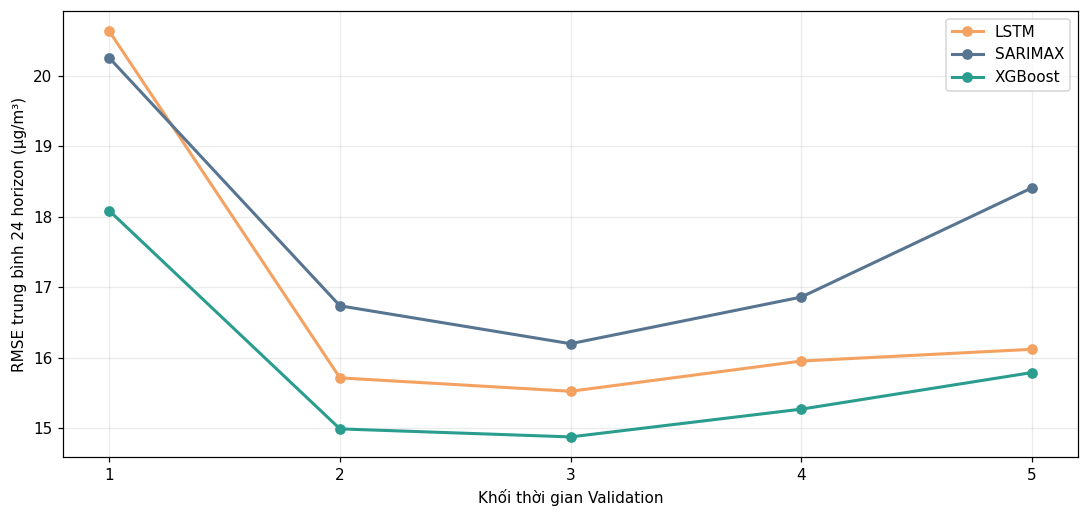

In [6]:
fig, axis = plt.subplots(figsize=(10, 4.8))
for model, part in cv_folds.groupby("model", sort=True):
    axis.plot(
        part["cv_fold"],
        part["mean_horizon_rmse_ug_m3"],
        marker="o",
        linewidth=2,
        label=model,
        color=MODEL_COLORS[model],
    )
axis.set_xticks(range(1, N_TEMPORAL_FOLDS + 1))
axis.set_xlabel("Khối thời gian Validation")
axis.set_ylabel("RMSE trung bình 24 horizon (µg/m³)")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "temporal_cv_fold_rmse.png", bbox_inches="tight")
plt.show()

*Hình 1. RMSE trung bình 24 chân trời của từng mô hình trên năm khối Validation
liên tiếp; đường thấp và ổn định hơn biểu thị khả năng tổng quát hóa theo thời gian
tốt hơn.*

## 4. Khóa lựa chọn trước khi mở Test

Mô hình được xếp hạng theo RMSE trung bình qua năm fold. Nếu hai mô hình bằng
nhau, thứ tự phụ lần lượt là độ lệch chuẩn RMSE, worst-fold RMSE và MAE trung bình.
Khoảng tin cậy 95% chỉ mô tả biến thiên giữa năm khối; với năm fold, không nên diễn
giải nó như bằng chứng thống kê tuyệt đối.

In [7]:
t_critical = float(student_t.ppf(0.975, df=N_TEMPORAL_FOLDS - 1))
cv_summary = (
    cv_folds.groupby("model")
    .agg(
        cv_mean_rmse_ug_m3=("mean_horizon_rmse_ug_m3", "mean"),
        cv_std_rmse_ug_m3=("mean_horizon_rmse_ug_m3", "std"),
        cv_worst_fold_rmse_ug_m3=("mean_horizon_rmse_ug_m3", "max"),
        cv_mean_mae_ug_m3=("mean_horizon_mae_ug_m3", "mean"),
        cv_mean_rank=("fold_rank", "mean"),
        fold_wins=("fold_rank", lambda values: int((values == 1).sum())),
    )
    .reset_index()
)
cv_summary["cv_se_rmse_ug_m3"] = cv_summary["cv_std_rmse_ug_m3"] / np.sqrt(N_TEMPORAL_FOLDS)
cv_summary["cv_ci95_low_ug_m3"] = (
    cv_summary["cv_mean_rmse_ug_m3"] - t_critical * cv_summary["cv_se_rmse_ug_m3"]
)
cv_summary["cv_ci95_high_ug_m3"] = (
    cv_summary["cv_mean_rmse_ug_m3"] + t_critical * cv_summary["cv_se_rmse_ug_m3"]
)
cv_summary = cv_summary.sort_values(
    [
        "cv_mean_rmse_ug_m3",
        "cv_std_rmse_ug_m3",
        "cv_worst_fold_rmse_ug_m3",
        "cv_mean_mae_ug_m3",
    ]
).reset_index(drop=True)
cv_summary.insert(0, "selection_rank", np.arange(1, len(cv_summary) + 1))

# Test chưa được đọc trong phép xếp hạng này.
selected_model = str(cv_summary.iloc[0]["model"])
runner_up_model = str(cv_summary.iloc[1]["model"])
cv_summary.to_csv(
    RESULTS_DIR / "multihorizon_temporal_cv_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(cv_summary)
print(f"Mô hình đã khóa bằng temporal CV: {selected_model}")

,selection_rank,model,cv_mean_rmse_ug_m3,cv_std_rmse_ug_m3,cv_worst_fold_rmse_ug_m3,cv_mean_mae_ug_m3,cv_mean_rank,fold_wins,cv_se_rmse_ug_m3,cv_ci95_low_ug_m3,cv_ci95_high_ug_m3
0,1,XGBoost,15.801271,1.323940,18.084112,9.763672,1.0,5,0.592084,14.157382,17.445160
1,2,LSTM,16.787373,2.160324,20.630523,10.503051,2.2,0,0.966126,14.104976,19.469769
2,3,SARIMAX,17.690839,1.651668,20.252635,10.989683,2.8,0,0.738648,15.640022,19.741656


Mô hình đã khóa bằng temporal CV: XGBoost


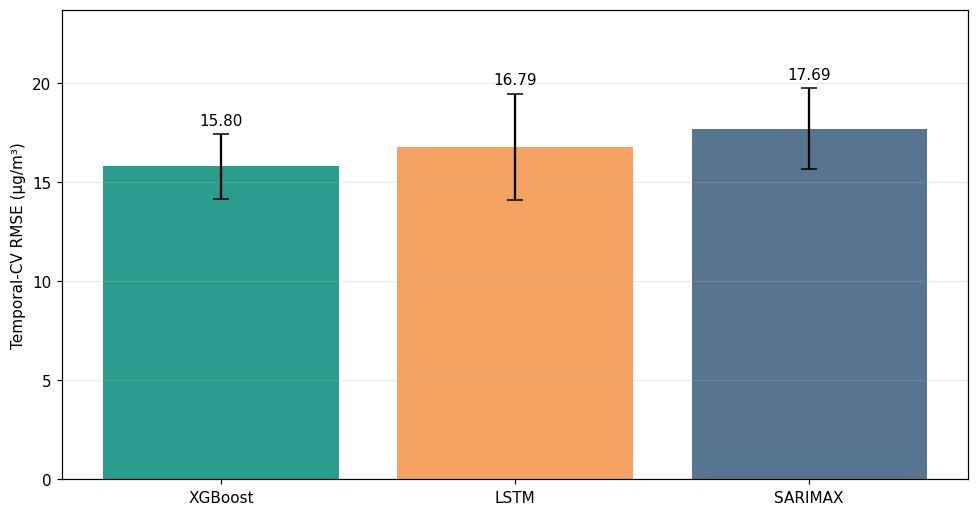

In [8]:
fig, axis = plt.subplots(figsize=(9, 4.8))
ordered = cv_summary.set_index("model")
positions = np.arange(len(ordered))
bars = axis.bar(
    positions,
    ordered["cv_mean_rmse_ug_m3"],
    yerr=t_critical * ordered["cv_se_rmse_ug_m3"],
    capsize=5,
    color=[MODEL_COLORS[model] for model in ordered.index],
)
axis.set_xticks(positions, ordered.index)
axis.set_ylabel("Temporal-CV RMSE (µg/m³)")
axis.grid(axis="y", alpha=0.25)
axis.bar_label(bars, labels=[f"{value:.2f}" for value in ordered["cv_mean_rmse_ug_m3"]], padding=4)
axis.margins(y=0.20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "temporal_cv_model_selection.png", bbox_inches="tight")
plt.show()

*Hình 2. RMSE trung bình qua năm khối Validation và khoảng tin cậy 95% theo biến
thiên giữa các khối. Cột thấp hơn là tốt hơn.*

In [9]:
winner_cv = cv_summary.iloc[0]
runner_cv = cv_summary.iloc[1]
improvement = float(runner_cv["cv_mean_rmse_ug_m3"] - winner_cv["cv_mean_rmse_ug_m3"])
relative_improvement = 100.0 * improvement / float(runner_cv["cv_mean_rmse_ug_m3"])

display(Markdown(
    f"**Nhận xét lựa chọn.** {selected_model} đạt temporal-CV RMSE trung bình "
    f"**{winner_cv['cv_mean_rmse_ug_m3']:.2f} ± {winner_cv['cv_std_rmse_ug_m3']:.2f} "
    f"µg/m³**, thắng **{int(winner_cv['fold_wins'])}/{N_TEMPORAL_FOLDS}** fold. "
    f"Mô hình đứng thứ hai là {runner_up_model} với "
    f"**{runner_cv['cv_mean_rmse_ug_m3']:.2f} µg/m³**. Chênh lệch tuyệt đối "
    f"là **{improvement:.2f} µg/m³** ({relative_improvement:.1f}%). "
    "Quyết định này chỉ sử dụng Validation; Test chưa tham gia xếp hạng."
))

**Nhận xét lựa chọn.** XGBoost đạt temporal-CV RMSE trung bình **15.80 ± 1.32 µg/m³**, thắng **5/5** fold. Mô hình đứng thứ hai là LSTM với **16.79 µg/m³**. Chênh lệch tuyệt đối là **0.99 µg/m³** (5.9%). Quyết định này chỉ sử dụng Validation; Test chưa tham gia xếp hạng.

## 5. Đánh giá Test sau khi đã chọn model

Sau khi `selected_model` được khóa, Test được mở để báo cáo khả năng tổng quát hóa.
Bảng so sánh tất cả candidate trên Test phục vụ thảo luận, không được dùng để đổi
ngược quyết định lựa chọn.

In [10]:
test_summary = (
    summary.loc[summary["split"].eq("test")]
    .sort_values("mean_horizon_rmse_ug_m3")
    .reset_index(drop=True)
)
selected_test = test_summary.loc[test_summary["model"].eq(selected_model)].iloc[0]
display(test_summary)

selection = {
    "selected_model": selected_model,
    "selection_protocol": "five contiguous validation blocks; fixed trained candidates",
    "selection_metric": "mean of per-fold mean-horizon RMSE",
    "selected_without_test_metrics": True,
    "temporal_folds": fold_manifest.assign(
        first_origin=fold_manifest["first_origin"].astype(str),
        last_origin=fold_manifest["last_origin"].astype(str),
    ).to_dict(orient="records"),
    "cross_validation": {
        "folds": N_TEMPORAL_FOLDS,
        "mean_rmse_ug_m3": float(winner_cv["cv_mean_rmse_ug_m3"]),
        "std_rmse_ug_m3": float(winner_cv["cv_std_rmse_ug_m3"]),
        "worst_fold_rmse_ug_m3": float(winner_cv["cv_worst_fold_rmse_ug_m3"]),
        "mean_mae_ug_m3": float(winner_cv["cv_mean_mae_ug_m3"]),
        "fold_wins": int(winner_cv["fold_wins"]),
    },
    "reported_test_metrics": {
        "mean_horizon_rmse_ug_m3": float(selected_test["mean_horizon_rmse_ug_m3"]),
        "mean_horizon_mae_ug_m3": float(selected_test["mean_horizon_mae_ug_m3"]),
        "global_rmse_ug_m3": float(selected_test["global_rmse_ug_m3"]),
        "global_mae_ug_m3": float(selected_test["global_mae_ug_m3"]),
        "global_r2": float(selected_test["global_r2"]),
        "global_bias_ug_m3": float(selected_test["global_bias_ug_m3"]),
    },
    "selected_artifact": str(MODEL_ARTIFACTS[selected_model].relative_to(PROJECT_ROOT)),
    "deployment_status": (
        "Selected artifact is used by web."
        if selected_model == "XGBoost"
        else "web must be updated before this selected artifact is deployed."
    ),
}
(RESULTS_DIR / "multihorizon_model_selection.json").write_text(
    json.dumps(selection, ensure_ascii=False, indent=2), encoding="utf-8"
)

,model,split,mean_horizon_rmse_ug_m3,mean_horizon_mae_ug_m3,global_rmse_ug_m3,global_mae_ug_m3,global_r2,global_bias_ug_m3
0,XGBoost,test,14.012522,8.910852,14.384410,8.910852,0.664944,-0.288406
1,LSTM,test,15.259917,9.893819,15.336945,9.893819,0.619100,0.075982
2,SARIMAX,test,16.007236,9.847911,16.367168,9.847911,0.566209,-0.546474


1789

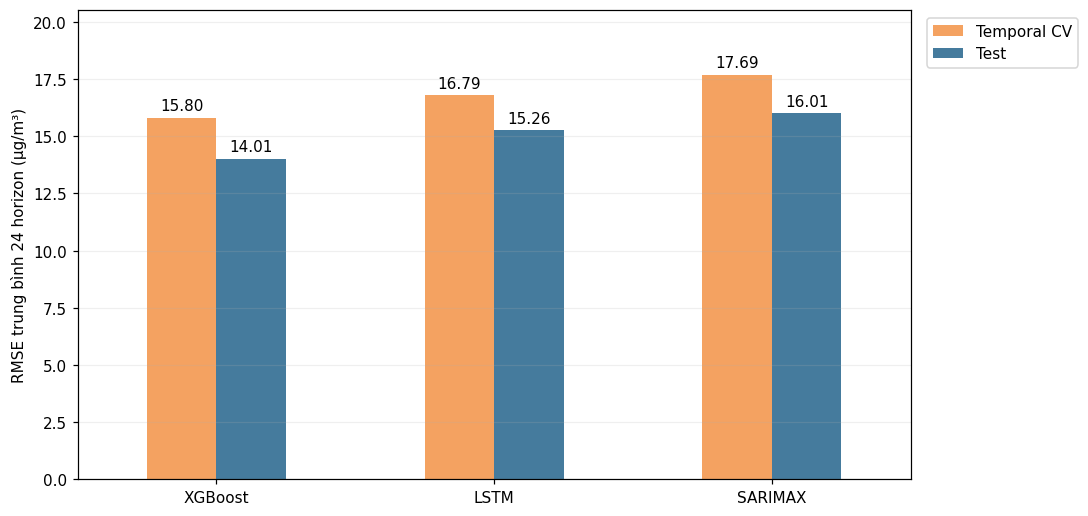

In [11]:
plot_frame = pd.concat([
    cv_summary[["model", "cv_mean_rmse_ug_m3"]].rename(
        columns={"cv_mean_rmse_ug_m3": "Temporal CV"}
    ).set_index("model"),
    test_summary[["model", "mean_horizon_rmse_ug_m3"]].rename(
        columns={"mean_horizon_rmse_ug_m3": "Test"}
    ).set_index("model"),
], axis=1).reindex(cv_summary["model"])

axis = plot_frame.plot(
    kind="bar",
    figsize=(10, 4.8),
    color=["#f4a261", "#457b9d"],
)
axis.set_xlabel("")
axis.set_ylabel("RMSE trung bình 24 horizon (µg/m³)")
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y", alpha=0.2)
axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
for container in axis.containers:
    axis.bar_label(container, fmt="%.2f", padding=3)
axis.margins(y=0.16)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cv_vs_test_model_comparison.png", bbox_inches="tight")
plt.show()

*Hình 3. RMSE temporal-CV và Test của ba mô hình. Test được báo cáo sau khi model
đã được khóa bằng Validation.*

## 6. Hiệu năng của model tốt nhất theo chân trời

RMSE, MAE, R² và bias được tính riêng ở từng `t+h`. Phân tích này cho biết sai số
tăng nhanh đến đâu khi khoảng dự báo dài hơn.

,model,split,horizon,rows,rmse_ug_m3,mae_ug_m3,r2,bias_ug_m3
96,XGBoost,test,1,14679,4.010591,2.156187,0.973983,-0.005006
97,XGBoost,test,2,14679,6.641553,3.877911,0.928664,-0.149269
98,XGBoost,test,3,14679,8.986221,5.444720,0.869403,-0.317303
99,XGBoost,test,4,14679,10.538060,6.580879,0.820386,-0.286618
100,XGBoost,test,5,14679,11.913590,7.561895,0.770414,-0.294905
101,XGBoost,test,6,14679,12.854752,8.176971,0.732686,-0.507072
102,XGBoost,test,7,14679,13.564640,8.650939,0.702333,-0.596423
103,XGBoost,test,8,14679,14.336814,9.122432,0.667462,-0.734478
104,XGBoost,test,9,14679,14.761199,9.370757,0.647469,-0.862817
105,XGBoost,test,10,14679,15.285613,9.698870,0.621961,-0.863639


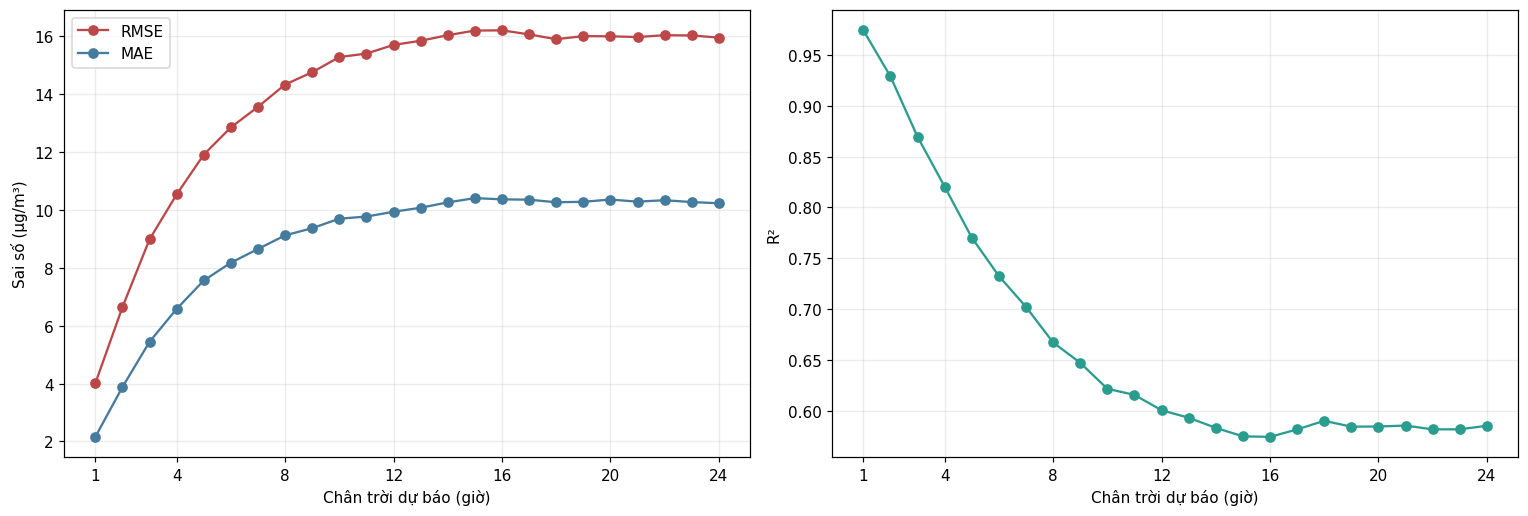

**Nhận xét.** RMSE tăng từ **4.01 µg/m³** ở t+1 lên **15.96 µg/m³** ở t+24. Chân trời khó nhất là **t+16** với RMSE **16.21 µg/m³**. Đây là xu hướng hợp lý vì thông tin từ trạng thái hiện tại giảm dần khi horizon tăng.

In [12]:
selected_horizon_test = by_horizon.loc[
    by_horizon["model"].eq(selected_model) & by_horizon["split"].eq("test")
].sort_values("horizon")
display(selected_horizon_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(
    selected_horizon_test["horizon"], selected_horizon_test["rmse_ug_m3"],
    marker="o", label="RMSE", color="#bc4749"
)
axes[0].plot(
    selected_horizon_test["horizon"], selected_horizon_test["mae_ug_m3"],
    marker="o", label="MAE", color="#457b9d"
)
axes[1].plot(
    selected_horizon_test["horizon"], selected_horizon_test["r2"],
    marker="o", color="#2a9d8f"
)
axes[0].set_ylabel("Sai số (µg/m³)")
axes[1].set_ylabel("R²")
for axis in axes:
    axis.set_xlabel("Chân trời dự báo (giờ)")
    axis.set_xticks([1, 4, 8, 12, 16, 20, 24])
    axis.grid(alpha=0.25)
axes[0].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_model_metrics_by_horizon.png", bbox_inches="tight")
plt.show()

worst_horizon = selected_horizon_test.loc[selected_horizon_test["rmse_ug_m3"].idxmax()]
first_horizon = selected_horizon_test.iloc[0]
last_horizon = selected_horizon_test.iloc[-1]
display(Markdown(
    f"**Nhận xét.** RMSE tăng từ **{first_horizon['rmse_ug_m3']:.2f} µg/m³** ở t+1 "
    f"lên **{last_horizon['rmse_ug_m3']:.2f} µg/m³** ở t+24. Chân trời khó nhất "
    f"là **t+{int(worst_horizon['horizon'])}** với RMSE "
    f"**{worst_horizon['rmse_ug_m3']:.2f} µg/m³**. Đây là xu hướng hợp lý vì "
    "thông tin từ trạng thái hiện tại giảm dần khi horizon tăng."
))

*Hình 4. RMSE, MAE và R² của model được chọn trên Test theo 24 chân trời.*

## 7. Độ ổn định theo thành phố

**Bảng 2.** Test RMSE, MAE, R² và bias theo thành phố của ba model; RMSE, MAE và
bias có đơn vị µg/m³.

,model,city,rows,rmse_ug_m3,mae_ug_m3,r2,bias_ug_m3
2,LSTM,Đà Nẵng,117432,6.860860,4.821862,0.540253,1.027400
1,LSTM,TP.HCM,117432,10.799167,8.419504,0.260154,4.292298
0,LSTM,Hà Nội,117432,23.280297,16.440091,0.459872,-5.091752
5,SARIMAX,Đà Nẵng,117432,6.962183,4.558127,0.526574,0.301093
4,SARIMAX,TP.HCM,117432,10.600093,7.265787,0.287180,-0.383360
3,SARIMAX,Hà Nội,117432,25.353868,17.719819,0.359369,-1.557154
8,XGBoost,Đà Nẵng,117432,6.656218,4.531341,0.567271,1.082675
7,XGBoost,TP.HCM,117432,9.895209,6.932588,0.378830,0.539817
6,XGBoost,Hà Nội,117432,21.874949,15.268627,0.523115,-2.487711


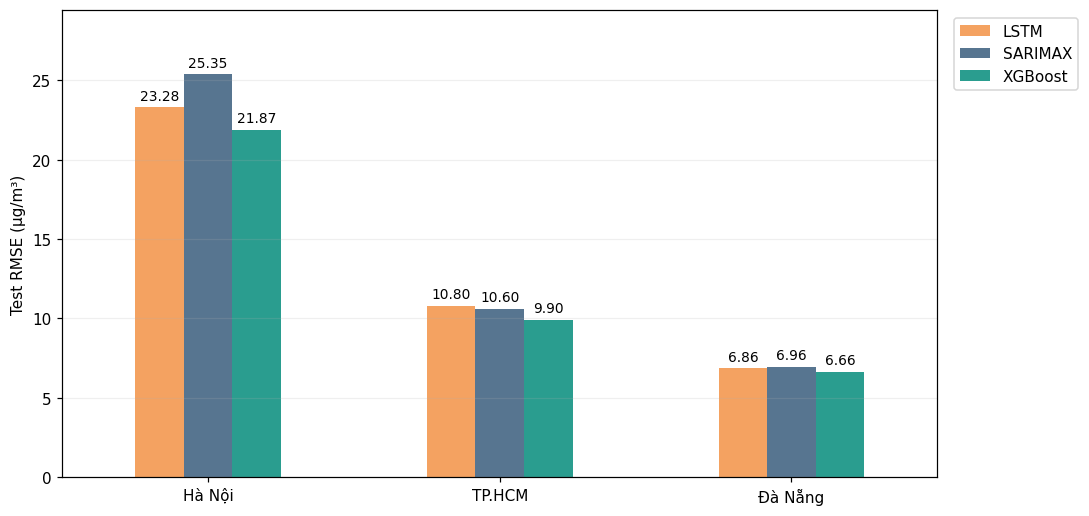

**Nhận xét.** Hà Nội là khu vực khó nhất đối với XGBoost, Test RMSE **21.87 µg/m³**; Đà Nẵng thấp nhất với **6.66 µg/m³**. Vì vậy metric tổng hợp phải luôn đi kèm phân tích địa lý.

In [13]:
city_rows = []
for (model, city), part in predictions.loc[predictions["split"].eq("test")].groupby(
    ["model", "city"], observed=True, sort=True
):
    city_rows.append({
        "model": str(model),
        "city": str(city),
        "rows": int(len(part)),
        **regression_metrics(part["actual_pm25"], part["predicted_pm25"]),
    })
by_city = pd.DataFrame(city_rows)
by_city.to_csv(
    RESULTS_DIR / "multihorizon_model_comparison_by_city.csv",
    index=False,
    encoding="utf-8-sig",
)
display(by_city.sort_values(["model", "rmse_ug_m3"]))

pivot = by_city.pivot(index="city", columns="model", values="rmse_ug_m3")
axis = pivot.plot(
    kind="bar",
    figsize=(10, 4.8),
    color=[MODEL_COLORS.get(model, "#777777") for model in pivot.columns],
)
axis.set_xlabel("")
axis.set_ylabel("Test RMSE (µg/m³)")
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y", alpha=0.2)
axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
for container in axis.containers:
    axis.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
axis.margins(y=0.16)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "test_rmse_by_city.png", bbox_inches="tight")
plt.show()

selected_city = by_city.loc[by_city["model"].eq(selected_model)]
hardest_city = selected_city.loc[selected_city["rmse_ug_m3"].idxmax()]
easiest_city = selected_city.loc[selected_city["rmse_ug_m3"].idxmin()]
display(Markdown(
    f"**Nhận xét.** {hardest_city['city']} là khu vực khó nhất đối với "
    f"{selected_model}, Test RMSE **{hardest_city['rmse_ug_m3']:.2f} µg/m³**; "
    f"{easiest_city['city']} thấp nhất với **{easiest_city['rmse_ug_m3']:.2f} µg/m³**. "
    "Vì vậy metric tổng hợp phải luôn đi kèm phân tích địa lý."
))

*Hình 5. Test RMSE theo thành phố và mô hình; cột thấp hơn là tốt hơn.*

## 8. Learning curve và chẩn đoán overfitting

Learning curve được đọc từ output huấn luyện của model đã chọn. Với XGBoost, mỗi
horizon có một bộ cây riêng; các đường tại t+1, t+6, t+12 và t+24 đại diện cho bốn
mức độ khó. Với LSTM, notebook hiển thị loss/metric theo epoch. SARIMAX không học
theo epoch nên không có learning curve cùng nghĩa.

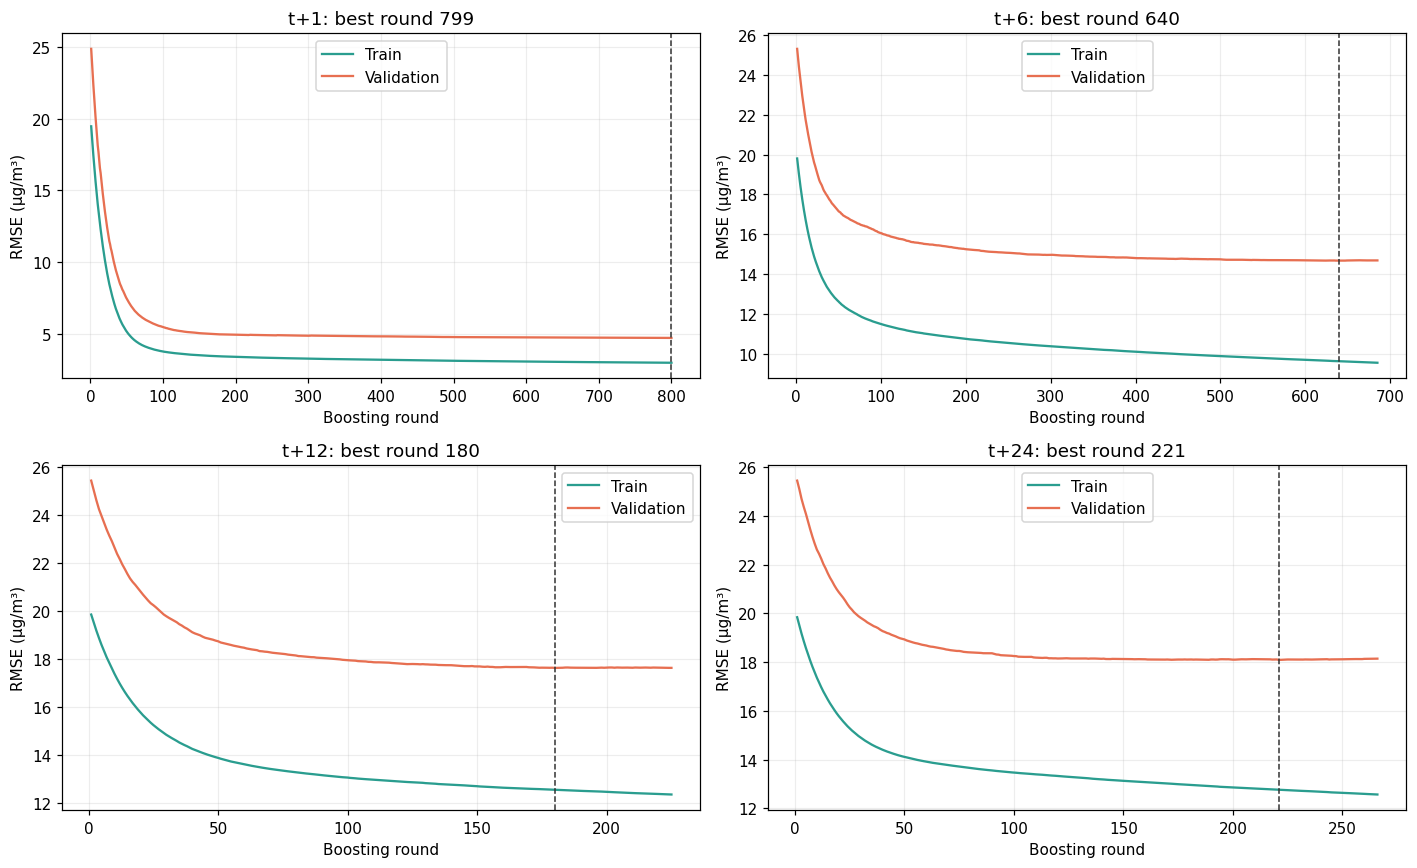

,horizon,best_round,train_rmse_at_best,validation_rmse_at_best,gap_rmse
0,1,799,2.995054,4.725476,1.730422
1,6,640,9.618049,14.667675,5.049626
2,12,180,12.553421,17.627595,5.074174
3,24,221,12.763552,18.095192,5.331640


**Chẩn đoán.** Khoảng cách Train–Validation RMSE tại best round của bốn horizon đại diện trung bình **4.30 µg/m³**. Train tiếp tục tốt hơn Validation, cho thấy mô hình có overfitting ở mức nhất định; early stopping đã ngăn việc chọn các vòng sau khi Validation không còn cải thiện.

In [14]:
if selected_model == "XGBoost":
    learning = pd.read_csv(RESULTS_DIR / "xgboost_multihorizon_learning_curves.csv")
    selected_curves = [1, 6, 12, 24]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    learning_diagnostics = []
    for axis, horizon in zip(axes.flat, selected_curves):
        part = learning.loc[learning["horizon"].eq(horizon)].sort_values("round")
        best_index = part["validation_rmse"].idxmin()
        best = part.loc[best_index]
        axis.plot(part["round"], part["train_rmse"], label="Train", color="#2a9d8f")
        axis.plot(part["round"], part["validation_rmse"], label="Validation", color="#e76f51")
        axis.axvline(best["round"], color="#333333", linestyle="--", linewidth=1)
        axis.set_title(f"t+{horizon}: best round {int(best['round'])}")
        axis.set_xlabel("Boosting round")
        axis.set_ylabel("RMSE (µg/m³)")
        axis.grid(alpha=0.22)
        axis.legend()
        learning_diagnostics.append({
            "horizon": horizon,
            "best_round": int(best["round"]),
            "train_rmse_at_best": float(best["train_rmse"]),
            "validation_rmse_at_best": float(best["validation_rmse"]),
            "gap_rmse": float(best["validation_rmse"] - best["train_rmse"]),
        })
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "best_model_learning_curves.png", bbox_inches="tight")
    plt.show()
    learning_diagnostics = pd.DataFrame(learning_diagnostics)
    display(learning_diagnostics)
    mean_gap = float(learning_diagnostics["gap_rmse"].mean())
    display(Markdown(
        f"**Chẩn đoán.** Khoảng cách Train–Validation RMSE tại best round của bốn "
        f"horizon đại diện trung bình **{mean_gap:.2f} µg/m³**. Train tiếp tục tốt "
        "hơn Validation, cho thấy mô hình có overfitting ở mức nhất định; early "
        "stopping đã ngăn việc chọn các vòng sau khi Validation không còn cải thiện."
    ))
elif selected_model == "LSTM":
    learning = pd.read_csv(RESULTS_DIR / "lstm_multihorizon_learning_curve.csv")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for axis, (train_col, val_col, label) in zip(axes, [
        ("loss", "val_loss", "MSE loss"),
        ("mae", "val_mae", "MAE chuẩn hóa"),
        ("rmse", "val_rmse", "RMSE chuẩn hóa"),
    ]):
        axis.plot(learning["epoch"], learning[train_col], label="Train")
        axis.plot(learning["epoch"], learning[val_col], label="Validation")
        axis.set_title(label)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.22)
        axis.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "best_model_learning_curves.png", bbox_inches="tight")
    plt.show()
else:
    display(Markdown(
        "SARIMAX được tối ưu bằng maximum likelihood, không huấn luyện theo epoch; "
        "trạng thái hội tụ và AIC trong `sarimax_fit_report.csv` thay cho learning curve."
    ))

*Hình 6. Learning curves của model được chọn trên các chân trời đại diện; đường
Validation quyết định thời điểm dừng, không phải đường Train.*

## 9. Feature importance của model được chọn

Nếu XGBoost thắng, importance được lấy trung bình từ 24 bộ cây độc lập. Đây là mức
độ sử dụng feature trong cây, không chứng minh quan hệ nhân quả.

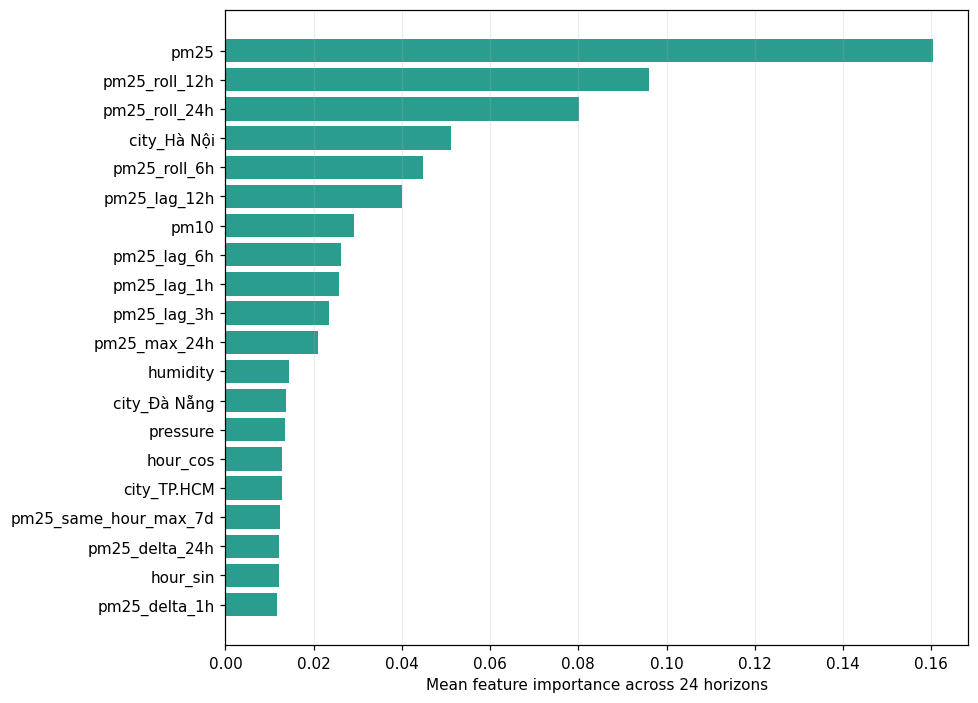

,feature,mean_importance,std_importance
24,pm25,0.160338,0.216638
42,pm25_roll_12h,0.096113,0.125427
44,pm25_roll_24h,0.080167,0.089467
1,city_Hà Nội,0.051170,0.021534
45,pm25_roll_6h,0.044785,0.087361
29,pm25_lag_12h,0.039951,0.061477
23,pm10,0.029254,0.052804
36,pm25_lag_6h,0.026217,0.046665
32,pm25_lag_1h,0.025857,0.056901
34,pm25_lag_3h,0.023468,0.038556


In [15]:
if selected_model == "XGBoost":
    artifact = joblib.load(MODEL_ARTIFACTS[selected_model])
    feature_columns = list(artifact["feature_columns"])
    importance_rows = []
    for horizon, model in artifact["models"].items():
        for feature, importance in zip(feature_columns, model.feature_importances_):
            importance_rows.append({
                "horizon": int(horizon),
                "feature": feature,
                "importance": float(importance),
            })
    importance = (
        pd.DataFrame(importance_rows)
        .groupby("feature", as_index=False)
        .agg(mean_importance=("importance", "mean"), std_importance=("importance", "std"))
        .sort_values("mean_importance", ascending=False)
    )
    importance.to_csv(
        RESULTS_DIR / "multihorizon_best_feature_importance.csv",
        index=False,
        encoding="utf-8-sig",
    )
    top_importance = importance.head(20).sort_values("mean_importance")
    fig, axis = plt.subplots(figsize=(9, 6.5))
    axis.barh(top_importance["feature"], top_importance["mean_importance"], color="#2a9d8f")
    axis.set_xlabel("Mean feature importance across 24 horizons")
    axis.grid(axis="x", alpha=0.22)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "best_model_feature_importance.png", bbox_inches="tight")
    plt.show()
    display(importance.head(20))
else:
    display(Markdown(
        f"{selected_model} không có feature importance dạng cây. Phần này không "
        "ép tạo một đại lượng không tương đương."
    ))

*Hình 7. Hai mươi feature có importance trung bình cao nhất của XGBoost trên 24
chân trời; importance không phải hệ số tác động nhân quả.*

## 10. Khoảng dự báo conformal 90%

Bán kính khoảng dự báo được hiệu chỉnh bằng absolute residual trên Validation
riêng cho từng thành phố và horizon. Test chỉ dùng để đo coverage và độ rộng sau
hiệu chỉnh, tránh lấy Test để xây khoảng.

,city,coverage,mean_width_ug_m3
0,Hà Nội,0.891188,64.358365
1,TP.HCM,0.949085,38.783835
2,Đà Nẵng,0.931705,21.797271


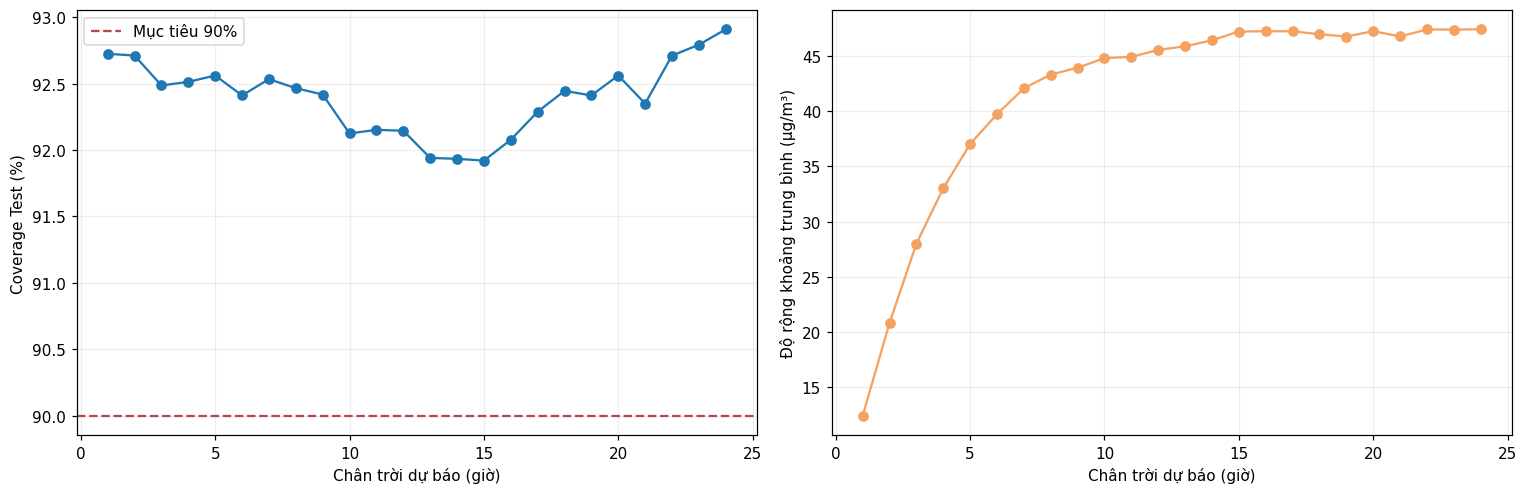

**Nhận xét.** Coverage thực nghiệm tổng hợp trên Test đạt **92.4%** so với mục tiêu danh nghĩa 90%. Coverage không bảo đảm đúng tại từng thời điểm; nó là tính chất thực nghiệm trên phân phối hiệu chỉnh/đánh giá hiện có.

In [16]:
selected_validation = predictions.loc[
    predictions["model"].eq(selected_model) & predictions["split"].eq("validation")
].copy()
selected_test_predictions = predictions.loc[
    predictions["model"].eq(selected_model) & predictions["split"].eq("test")
].copy()

calibration_rows = []
for (city, horizon), part in selected_validation.groupby(["city", "horizon"], observed=True):
    errors = np.abs(part["actual_pm25"].to_numpy() - part["predicted_pm25"].to_numpy())
    quantile_level = min(1.0, np.ceil((len(errors) + 1) * (1 - ALPHA)) / len(errors))
    radius = float(np.quantile(errors, quantile_level, method="higher"))
    calibration_rows.append({
        "city": str(city),
        "horizon": int(horizon),
        "calibration_rows": int(len(errors)),
        "quantile_level": float(quantile_level),
        "radius_ug_m3": radius,
    })
calibration = pd.DataFrame(calibration_rows)

interval_test = selected_test_predictions.merge(
    calibration, on=["city", "horizon"], how="left", validate="many_to_one"
)
interval_test["lower_pm25"] = np.clip(
    interval_test["predicted_pm25"] - interval_test["radius_ug_m3"], 0.0, None
)
interval_test["upper_pm25"] = interval_test["predicted_pm25"] + interval_test["radius_ug_m3"]
interval_test["covered"] = (
    interval_test["actual_pm25"].ge(interval_test["lower_pm25"])
    & interval_test["actual_pm25"].le(interval_test["upper_pm25"])
)
interval_test["width_ug_m3"] = interval_test["upper_pm25"] - interval_test["lower_pm25"]

coverage_horizon = (
    interval_test.groupby("horizon")
    .agg(coverage=("covered", "mean"), mean_width_ug_m3=("width_ug_m3", "mean"))
    .reset_index()
)
coverage_city = (
    interval_test.groupby("city", observed=True)
    .agg(coverage=("covered", "mean"), mean_width_ug_m3=("width_ug_m3", "mean"))
    .reset_index()
)
overall_coverage = float(interval_test["covered"].mean())
coverage_horizon.to_csv(
    RESULTS_DIR / "multihorizon_best_conformal_coverage_by_horizon.csv",
    index=False,
    encoding="utf-8-sig",
)
coverage_city.to_csv(
    RESULTS_DIR / "multihorizon_best_conformal_coverage_by_city.csv",
    index=False,
    encoding="utf-8-sig",
)
display(coverage_city)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(coverage_horizon["horizon"], 100 * coverage_horizon["coverage"], marker="o")
axes[0].axhline(90, color="#bc4749", linestyle="--", label="Mục tiêu 90%")
axes[0].set_ylabel("Coverage Test (%)")
axes[0].legend()
axes[1].plot(
    coverage_horizon["horizon"], coverage_horizon["mean_width_ug_m3"],
    marker="o", color="#f4a261"
)
axes[1].set_ylabel("Độ rộng khoảng trung bình (µg/m³)")
for axis in axes:
    axis.set_xlabel("Chân trời dự báo (giờ)")
    axis.grid(alpha=0.22)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_model_conformal_coverage.png", bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Nhận xét.** Coverage thực nghiệm tổng hợp trên Test đạt "
    f"**{100 * overall_coverage:.1f}%** so với mục tiêu danh nghĩa 90%. "
    "Coverage không bảo đảm đúng tại từng thời điểm; nó là tính chất thực nghiệm "
    "trên phân phối hiệu chỉnh/đánh giá hiện có."
))

*Hình 8. Coverage và độ rộng khoảng conformal 90% trên Test theo chân trời.*

## 11. Dự báo trực quan trên phần cuối tập Test

Hình dưới đây lấy riêng lát cắt `t+24` của model đa chân trời để có thể đọc như một chuỗi thời gian và đối chiếu trực tiếp với mô hình `t+24` cũ. Mỗi thành phố hiển thị 240 giờ mục tiêu cuối của Test; khoảng conformal được hiệu chỉnh trên Validation, không dùng Test để xây khoảng.

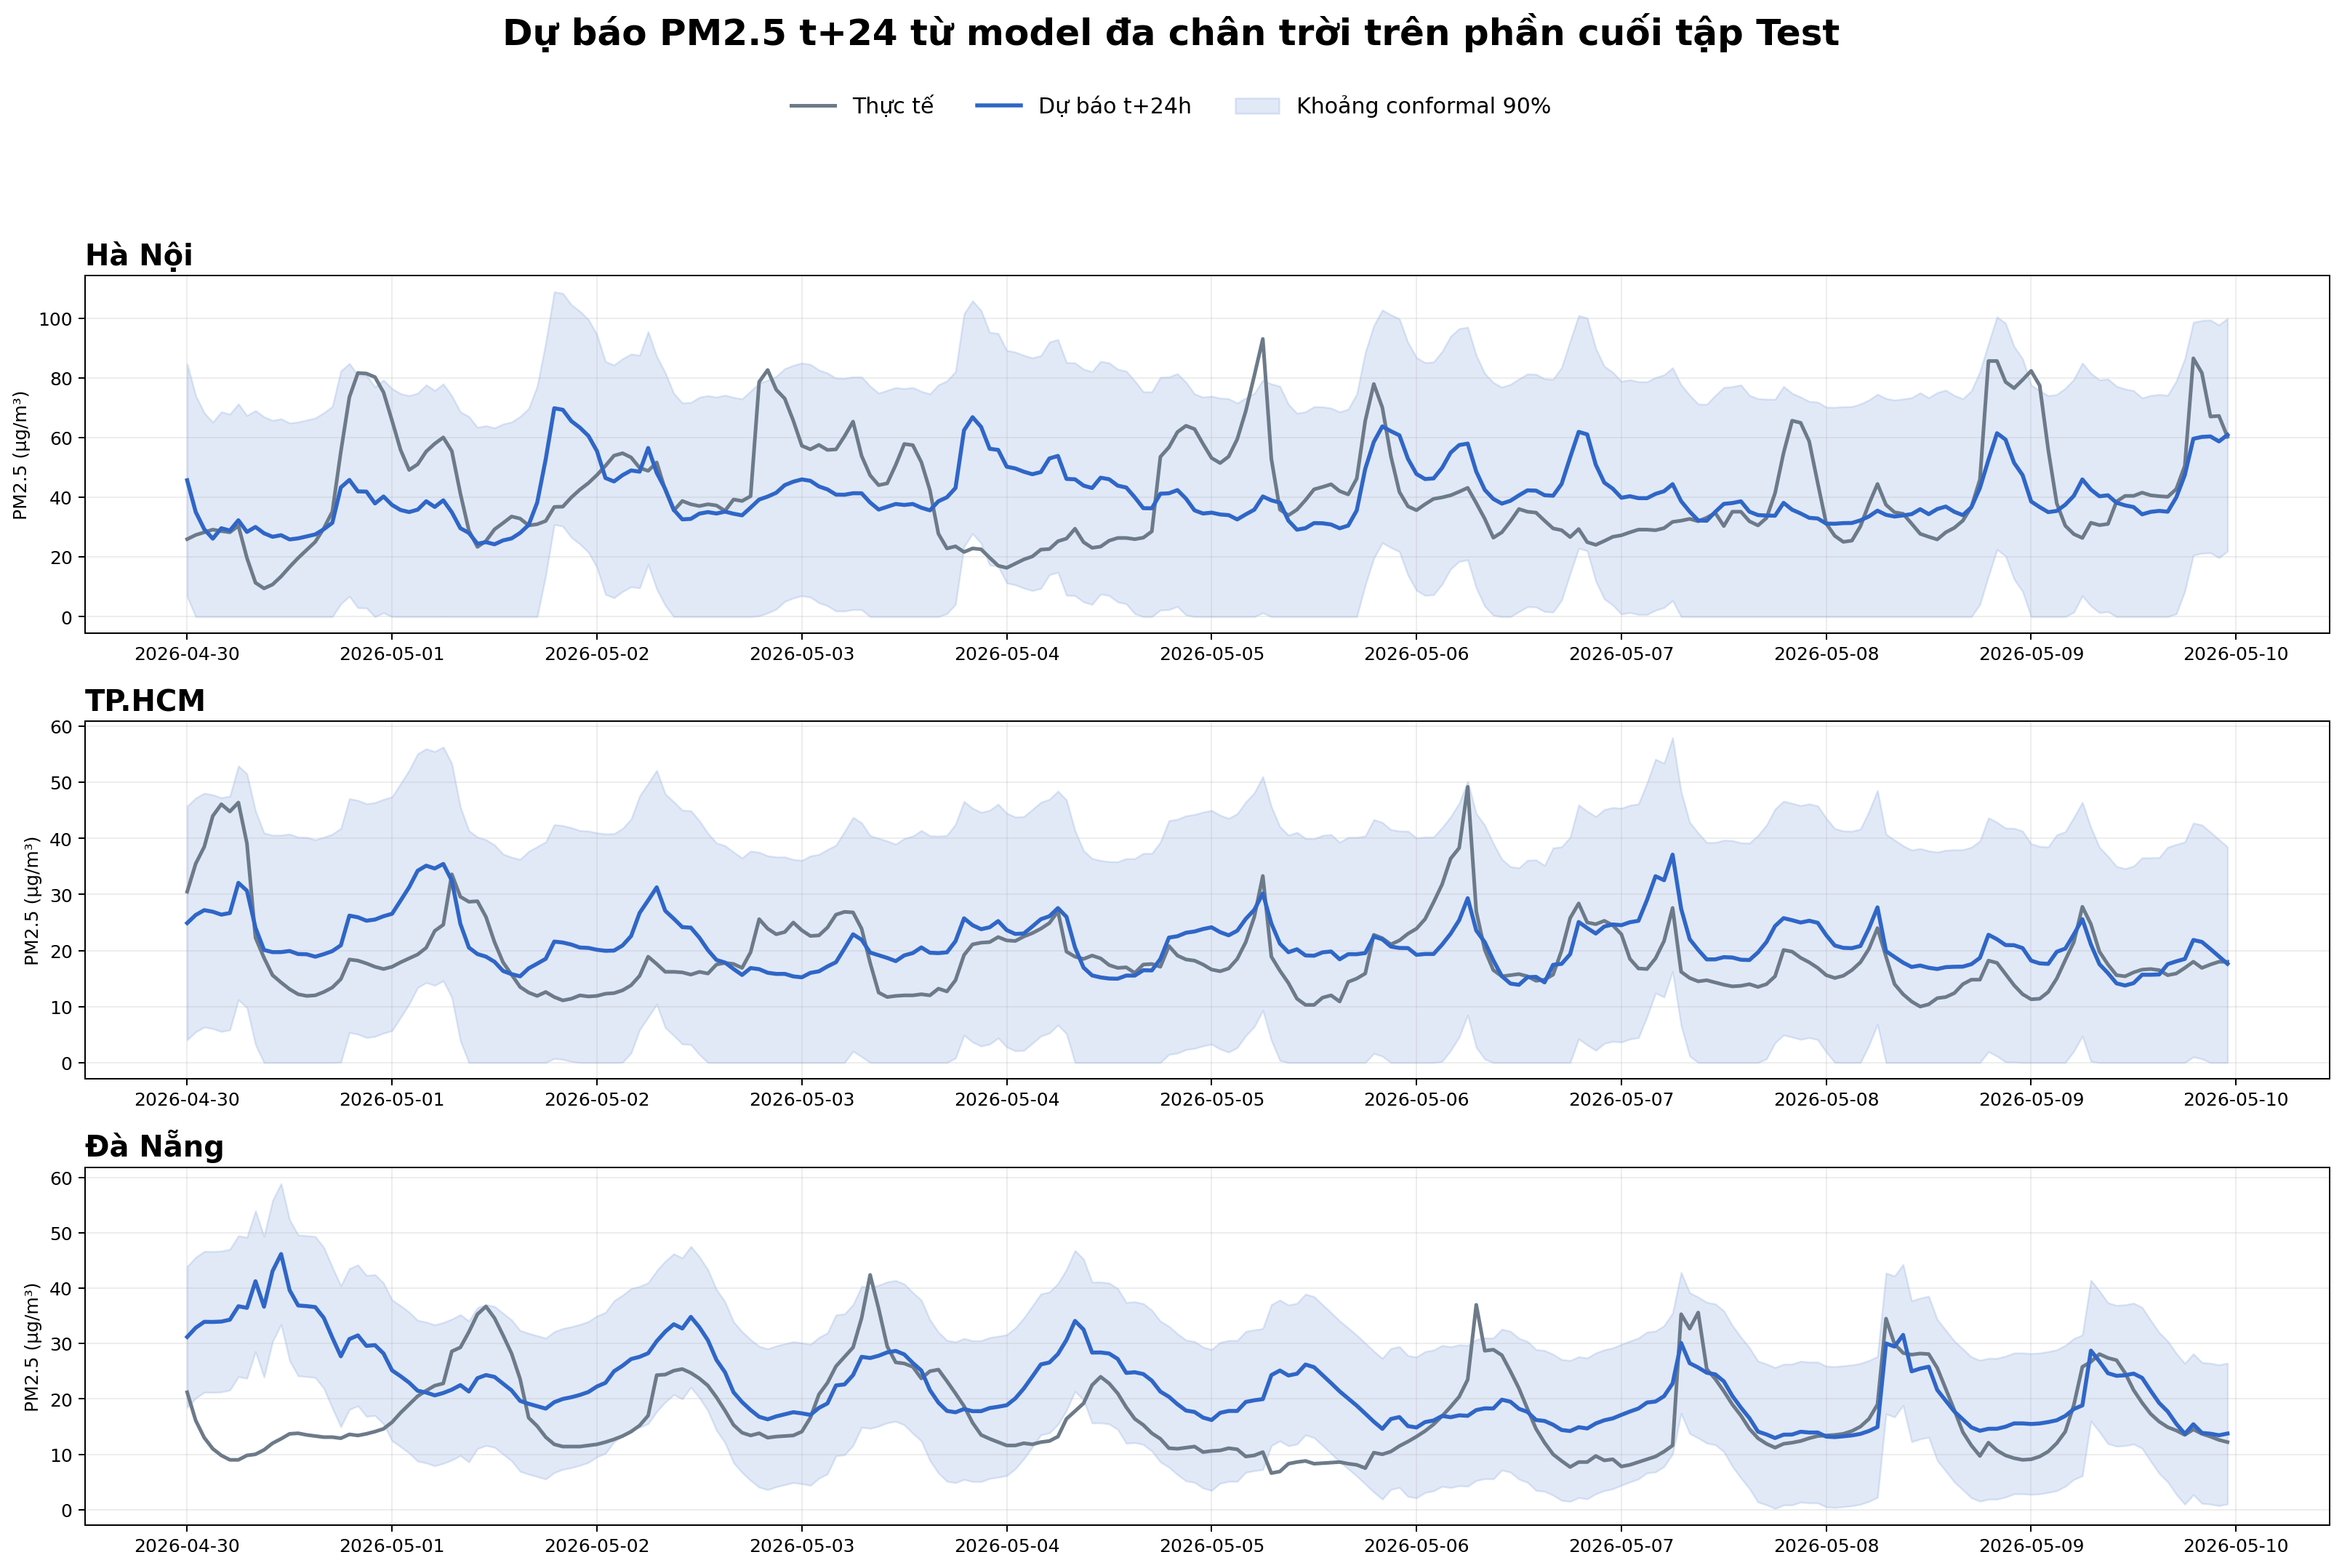

model\figures\best_model_test_forecast.png


In [22]:
TEST_FORECAST_HORIZON = 24
WINDOW_HOURS = 240
forecast_tail = interval_test.loc[
    interval_test["horizon"].eq(TEST_FORECAST_HORIZON)
].copy()
forecast_tail["target_time"] = pd.to_datetime(forecast_tail["target_time"])
cities = forecast_tail["city"].drop_duplicates().tolist()

actual_label = "Th" + chr(0x1EF1) + "c t" + chr(0x1EBF)
forecast_label = "D" + chr(0x1EF1) + " b" + chr(0x00E1) + "o t+24h"
interval_label = "Kho" + chr(0x1EA3) + "ng conformal 90%"
figure_title = (
    "D" + chr(0x1EF1) + " b" + chr(0x00E1) + "o PM2.5 t+24 t" + chr(0x1EEB)
    + " model " + chr(0x0111) + "a ch" + chr(0x00E2) + "n tr" + chr(0x1EDD) + "i tr"
    + chr(0x00EA) + "n ph" + chr(0x1EA7) + "n cu" + chr(0x1ED1) + "i t"
    + chr(0x1EAD) + "p Test"
)
y_label = "PM2.5 (" + chr(0x00B5) + "g/m" + chr(0x00B3) + ")"

fig, axes = plt.subplots(len(cities), 1, figsize=(18, 12), sharex=False)
axes = np.atleast_1d(axes)
for axis, city in zip(axes, cities):
    city_frame = (
        forecast_tail.loc[forecast_tail["city"].eq(city)]
        .sort_values("target_time")
        .tail(WINDOW_HOURS)
    )
    axis.plot(
        city_frame["target_time"], city_frame["actual_pm25"],
        color="#6c7a89", linewidth=2.0, label=actual_label,
    )
    axis.plot(
        city_frame["target_time"], city_frame["predicted_pm25"],
        color="#2f66c7", linewidth=2.2, label=forecast_label,
    )
    axis.fill_between(
        city_frame["target_time"], city_frame["lower_pm25"], city_frame["upper_pm25"],
        color="#2f66c7", alpha=0.14, label=interval_label,
    )
    axis.set_title(str(city), loc="left", fontsize=16, fontweight="bold")
    axis.set_ylabel(y_label)
    axis.grid(alpha=0.22)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955),
    ncol=3, frameon=False, fontsize=12,
)
fig.suptitle(figure_title, fontsize=20, fontweight="bold", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.90))
output_path = FIGURES_DIR / "best_model_test_forecast.png"
fig.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()
print(output_path.relative_to(PROJECT_ROOT))

*Hình 9. PM2.5 thực tế, dự báo `t+24` của XGBoost đa chân trời và khoảng conformal 90% trên 240 giờ cuối của tập Test tại ba thành phố.*

## 12. Phân tích residual và các trường hợp sai

Residual được định nghĩa là `predicted - actual`: giá trị âm là dự báo thấp hơn thực
tế. Biểu đồ dùng mẫu ngẫu nhiên cố định để tránh che kín hình bởi hàng trăm nghìn
điểm, nhưng các bảng metric vẫn dùng toàn bộ Test.

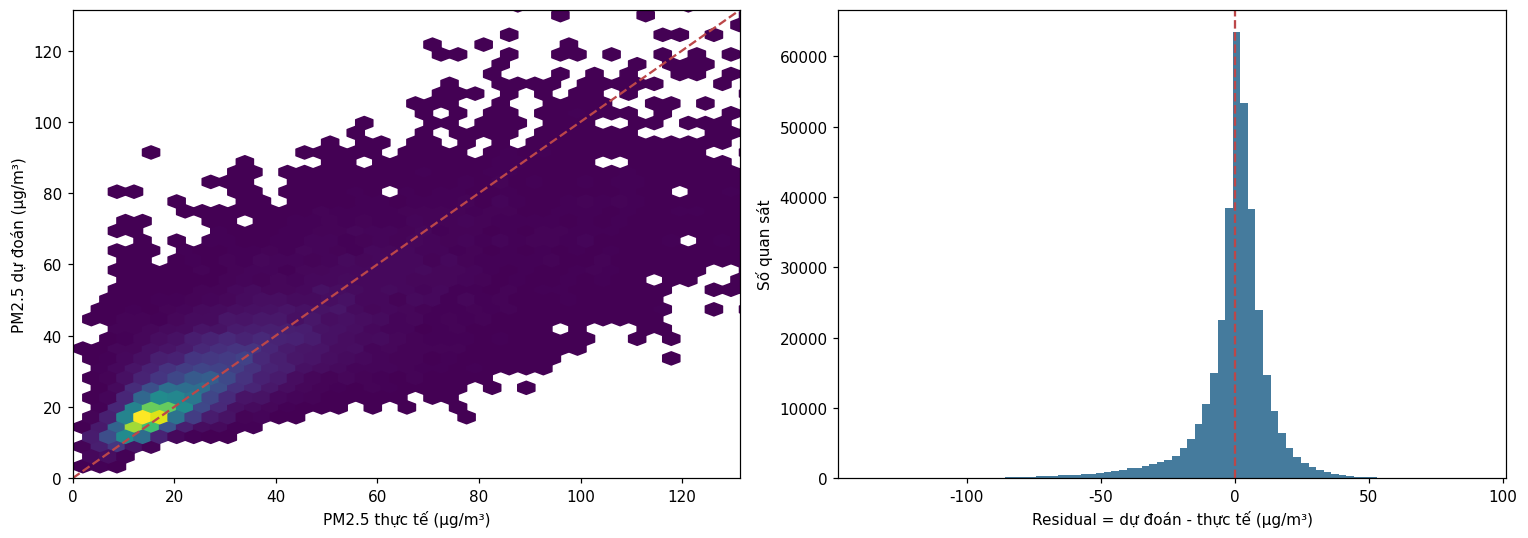

In [18]:
selected_test_predictions["predicted_pm25"] = np.clip(
    selected_test_predictions["predicted_pm25"], 0.0, None
)
selected_test_predictions["residual_ug_m3"] = (
    selected_test_predictions["predicted_pm25"] - selected_test_predictions["actual_pm25"]
)
selected_test_predictions["abs_error_ug_m3"] = selected_test_predictions["residual_ug_m3"].abs()

residual_summary = (
    selected_test_predictions.groupby(["city", "horizon"], observed=True)
    .agg(
        rows=("actual_pm25", "size"),
        mean_residual_ug_m3=("residual_ug_m3", "mean"),
        median_residual_ug_m3=("residual_ug_m3", "median"),
        mae_ug_m3=("abs_error_ug_m3", "mean"),
        p90_abs_error_ug_m3=("abs_error_ug_m3", lambda values: values.quantile(0.90)),
    )
    .reset_index()
)
residual_summary.to_csv(
    RESULTS_DIR / "multihorizon_best_residual_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

sample_size = min(30000, len(selected_test_predictions))
plot_sample = selected_test_predictions.sample(sample_size, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
axes[0].hexbin(
    plot_sample["actual_pm25"], plot_sample["predicted_pm25"],
    gridsize=55, mincnt=1, cmap="viridis"
)
limit = float(np.quantile(plot_sample[["actual_pm25", "predicted_pm25"]].to_numpy(), 0.995))
axes[0].plot([0, limit], [0, limit], color="#bc4749", linestyle="--")
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("PM2.5 thực tế (µg/m³)")
axes[0].set_ylabel("PM2.5 dự đoán (µg/m³)")
axes[1].hist(selected_test_predictions["residual_ug_m3"], bins=80, color="#457b9d")
axes[1].axvline(0, color="#bc4749", linestyle="--")
axes[1].set_xlabel("Residual = dự đoán - thực tế (µg/m³)")
axes[1].set_ylabel("Số quan sát")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_model_residual_analysis.png", bbox_inches="tight")
plt.show()

*Hình 10. Quan hệ PM2.5 thực tế–dự đoán và phân phối residual của model được chọn
trên Test.*

## 13. Confusion matrix chẩn đoán theo dải PM2.5

Đây vẫn là **bài toán hồi quy**. Sáu dải PM2.5 được nhóm tự quy ước để quan sát
model bỏ lỡ mức ô nhiễm nào; chúng không phải nhãn AQI chính thức và không thay đổi
target huấn luyện.

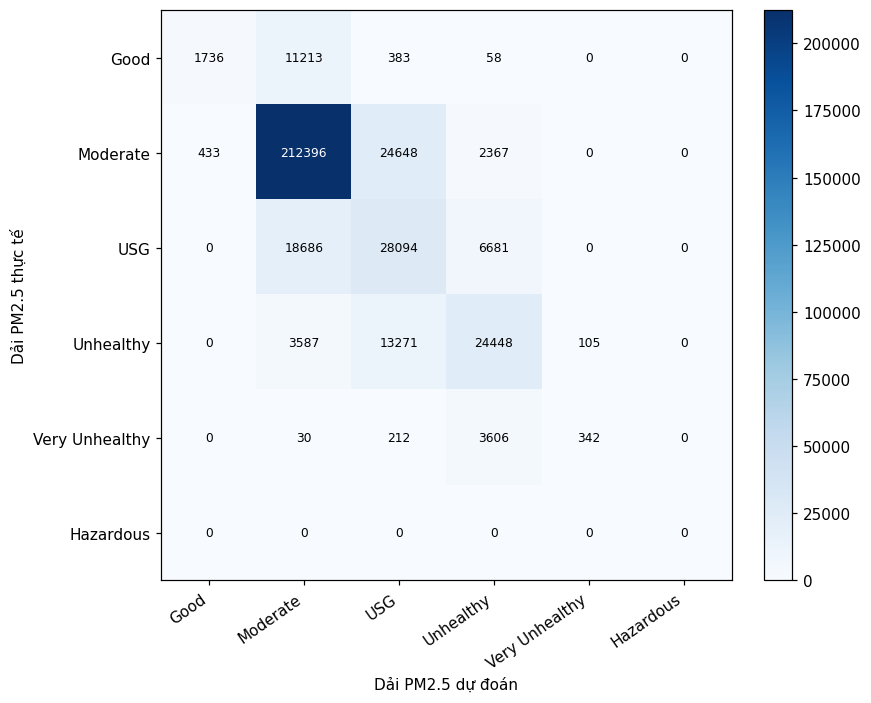

,precision,recall,f1-score,support
Good,0.800369,0.129649,0.223151,13390.000000
Moderate,0.863707,0.885559,0.874497,239844.000000
USG,0.421781,0.525505,0.467964,53461.000000
Unhealthy,0.657912,0.590375,0.622316,41411.000000
Very Unhealthy,0.765101,0.081623,0.147509,4190.000000
Hazardous,0.000000,0.000000,0.000000,0.000000
accuracy,0.757931,0.757931,0.757931,0.757931
macro avg,0.584812,0.368785,0.389239,352296.000000
weighted avg,0.768874,0.757931,0.749760,352296.000000


In [19]:
selected_test_predictions["actual_category"] = pd.cut(
    selected_test_predictions["actual_pm25"],
    PM25_BINS,
    labels=PM25_LABELS,
    include_lowest=True,
)
selected_test_predictions["predicted_category"] = pd.cut(
    selected_test_predictions["predicted_pm25"],
    PM25_BINS,
    labels=PM25_LABELS,
    include_lowest=True,
)

matrix = confusion_matrix(
    selected_test_predictions["actual_category"],
    selected_test_predictions["predicted_category"],
    labels=PM25_LABELS,
)
matrix_frame = pd.DataFrame(matrix, index=PM25_LABELS, columns=PM25_LABELS)
matrix_frame.to_csv(
    RESULTS_DIR / "multihorizon_best_confusion_matrix.csv",
    encoding="utf-8-sig",
)
report = pd.DataFrame(classification_report(
    selected_test_predictions["actual_category"],
    selected_test_predictions["predicted_category"],
    labels=PM25_LABELS,
    output_dict=True,
    zero_division=0,
)).T
report.to_csv(
    RESULTS_DIR / "multihorizon_best_classification_report.csv",
    encoding="utf-8-sig",
)

fig, axis = plt.subplots(figsize=(8.5, 6.5))
image = axis.imshow(matrix, cmap="Blues")
axis.set_xticks(np.arange(len(PM25_LABELS)), PM25_LABELS, rotation=35, ha="right")
axis.set_yticks(np.arange(len(PM25_LABELS)), PM25_LABELS)
axis.set_xlabel("Dải PM2.5 dự đoán")
axis.set_ylabel("Dải PM2.5 thực tế")
threshold = matrix.max() * 0.5
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        color = "white" if matrix[row, column] > threshold else "black"
        axis.text(
            column, row, int(matrix[row, column]),
            ha="center", va="center", color=color, fontsize=8,
        )
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_model_confusion_matrix.png", bbox_inches="tight")
plt.show()
display(report)

*Hình 11. Confusion matrix hậu xử lý của model hồi quy sau khi quy đổi PM2.5 sang
các dải do nhóm quy ước.*

In [20]:
top_errors = selected_test_predictions.nlargest(20, "abs_error_ug_m3")[
    [
        "city", "source_time", "target_time", "horizon", "actual_pm25",
        "predicted_pm25", "residual_ug_m3", "abs_error_ug_m3",
        "actual_category", "predicted_category",
    ]
]
top_errors.to_csv(
    RESULTS_DIR / "multihorizon_best_top_errors.csv",
    index=False,
    encoding="utf-8-sig",
)
display(top_errors)

macro_f1 = float(report.loc["macro avg", "f1-score"])
largest_error = top_errors.iloc[0]
under_at_peaks = selected_test_predictions.loc[
    selected_test_predictions["actual_pm25"].ge(
        selected_test_predictions["actual_pm25"].quantile(0.95)
    ),
    "residual_ug_m3",
].mean()
display(Markdown(
    f"**Phân tích lỗi.** Sai số tuyệt đối lớn nhất là "
    f"**{largest_error['abs_error_ug_m3']:.2f} µg/m³** tại {largest_error['city']} "
    f"ở t+{int(largest_error['horizon'])}. Macro F1 sau quy đổi dải là "
    f"**{macro_f1:.3f}**. Residual trung bình trong 5% quan sát PM2.5 thực tế cao "
    f"nhất là **{under_at_peaks:.2f} µg/m³**; giá trị âm xác nhận xu hướng làm "
    "trơn và đánh giá thấp một phần các đỉnh ô nhiễm hiếm. Các nguyên nhân hợp lý "
    "gồm biến động phát thải đột ngột, độ phân giải của dữ liệu khí tượng/CAMS và "
    "số mẫu cực đoan ít hơn nhiều so với các mức trung bình."
))

,city,source_time,target_time,horizon,actual_pm25,predicted_pm25,residual_ug_m3,abs_error_ug_m3,actual_category,predicted_category
1165847,Hà Nội,2026-04-24 06:00:00,2026-04-25 06:00:00,24,186.7,50.179604,-136.520396,136.520396,Very Unhealthy,USG
1165962,Hà Nội,2026-04-24 11:00:00,2026-04-25 06:00:00,19,186.7,50.987770,-135.712230,135.712230,Very Unhealthy,USG
1165893,Hà Nội,2026-04-24 08:00:00,2026-04-25 06:00:00,22,186.7,53.727341,-132.972659,132.972659,Very Unhealthy,USG
1165985,Hà Nội,2026-04-24 12:00:00,2026-04-25 06:00:00,18,186.7,53.854172,-132.845828,132.845828,Very Unhealthy,USG
1165870,Hà Nội,2026-04-24 07:00:00,2026-04-25 06:00:00,23,186.7,53.901649,-132.798351,132.798351,Very Unhealthy,USG
1166031,Hà Nội,2026-04-24 14:00:00,2026-04-25 06:00:00,16,186.7,54.246727,-132.453273,132.453273,Very Unhealthy,USG
1166054,Hà Nội,2026-04-24 15:00:00,2026-04-25 06:00:00,15,186.7,54.998421,-131.701579,131.701579,Very Unhealthy,USG
1166100,Hà Nội,2026-04-24 17:00:00,2026-04-25 06:00:00,13,186.7,55.067890,-131.632110,131.632110,Very Unhealthy,USG
1165823,Hà Nội,2026-04-24 05:00:00,2026-04-25 05:00:00,24,181.6,50.233463,-131.366537,131.366537,Very Unhealthy,USG
1165916,Hà Nội,2026-04-24 09:00:00,2026-04-25 06:00:00,21,186.7,55.750282,-130.949718,130.949718,Very Unhealthy,Unhealthy


**Phân tích lỗi.** Sai số tuyệt đối lớn nhất là **136.52 µg/m³** tại Hà Nội ở t+24. Macro F1 sau quy đổi dải là **0.389**. Residual trung bình trong 5% quan sát PM2.5 thực tế cao nhất là **-36.22 µg/m³**; giá trị âm xác nhận xu hướng làm trơn và đánh giá thấp một phần các đỉnh ô nhiễm hiếm. Các nguyên nhân hợp lý gồm biến động phát thải đột ngột, độ phân giải của dữ liệu khí tượng/CAMS và số mẫu cực đoan ít hơn nhiều so với các mức trung bình.

## 14. Kết luận

In [21]:
display(Markdown(
    f"1. **Mô hình được chọn: {selected_model}.** Model đạt temporal-CV RMSE "
    f"**{winner_cv['cv_mean_rmse_ug_m3']:.2f} µg/m³**, thắng "
    f"**{int(winner_cv['fold_wins'])}/{N_TEMPORAL_FOLDS}** khối Validation.\n"
    f"2. Sau khi khóa lựa chọn, Test RMSE trung bình 24 horizon là "
    f"**{selected_test['mean_horizon_rmse_ug_m3']:.2f} µg/m³**, MAE "
    f"**{selected_test['mean_horizon_mae_ug_m3']:.2f} µg/m³** và global R² "
    f"**{selected_test['global_r2']:.3f}**.\n"
    f"3. Điểm yếu chính nằm ở **{hardest_city['city']}**, horizon dài và các đỉnh "
    "PM2.5 hiếm. Khoảng conformal giúp biểu diễn bất định nhưng không sửa sai số "
    "điểm và không bảo đảm coverage trong mọi regime tương lai.\n"
    "4. Việc chọn model dựa trên nhiều khối thời gian làm kết luận vững hơn một "
    "Validation score duy nhất, đồng thời Test vẫn giữ đúng vai trò đánh giá cuối."
))

1. **Mô hình được chọn: XGBoost.** Model đạt temporal-CV RMSE **15.80 µg/m³**, thắng **5/5** khối Validation.
2. Sau khi khóa lựa chọn, Test RMSE trung bình 24 horizon là **14.01 µg/m³**, MAE **8.91 µg/m³** và global R² **0.665**.
3. Điểm yếu chính nằm ở **Hà Nội**, horizon dài và các đỉnh PM2.5 hiếm. Khoảng conformal giúp biểu diễn bất định nhưng không sửa sai số điểm và không bảo đảm coverage trong mọi regime tương lai.
4. Việc chọn model dựa trên nhiều khối thời gian làm kết luận vững hơn một Validation score duy nhất, đồng thời Test vẫn giữ đúng vai trò đánh giá cuối.

## Tài liệu tham khảo

1. Tashman, L. J. (2000). *Out-of-sample tests of forecasting accuracy: an
   analysis and review*. International Journal of Forecasting, 16(4), 437–450.
2. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*.
   Proceedings of the 22nd ACM SIGKDD.
3. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural
   Computation, 9(8), 1735–1780.
4. Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015).
   *Time Series Analysis: Forecasting and Control*. Wiley.